# ML Models — TON_IoT NLP Dataset
### Models: Logistic Regression | Naive Bayes | SVM | Random Forest | XGBoost
**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, MCC, Cohen's Kappa, Confusion Matrix

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('TON_IoT_NLP_Dataset.csv')
texts = df['text'].astype(str)
labels = df['label'].astype(int)

print('Dataset shape:', df.shape)
print('Label distribution:')
print(labels.value_counts())
df.head()

Dataset shape: (211043, 3)
Label distribution:
label
1    161043
0     50000
Name: count, dtype: int64


,text,label,type
0,tcp protocol connection state oth high duratio...,1,backdoor
1,tcp protocol connection state rej low duration...,1,backdoor
2,tcp protocol connection state rej low duration...,1,backdoor
3,tcp protocol connection state rej low duration...,1,backdoor
4,tcp protocol connection state rej low duration...,1,backdoor


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 168834
Test size: 42209


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # Unigrams + Bigrams
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print('TF-IDF matrix shape (train):', X_train_tfidf.shape)

TF-IDF matrix shape (train): (168834, 184)


In [5]:
# ─────────────────────────────────────────────────────────────
# Research-Paper Standard Evaluation Function
# Metrics: Accuracy, Precision, Recall, F1, ROC-AUC, MCC, Kappa
# Supports Binary + Multiclass
# ─────────────────────────────────────────────────────────────

import time
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

results_table = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, has_proba=True):

    # -------------------- Training --------------------
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # -------------------- Inference --------------------
    t1 = time.time()
    y_pred = model.predict(X_te)
    infer_time = time.time() - t1

    # -------------------- Probabilities --------------------
    y_prob = None
    if has_proba and hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_te)

    # -------------------- Core Metrics --------------------
    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1    = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    mcc   = matthews_corrcoef(y_te, y_pred)
    kappa = cohen_kappa_score(y_te, y_pred)

    # -------------------- ROC-AUC (Binary & Multiclass Safe) --------------------
    auc = None
    try:
        if len(np.unique(y_te)) == 2:
            if y_prob is not None:
                if y_prob.ndim > 1:
                    auc = roc_auc_score(y_te, y_prob[:, 1])
                else:
                    auc = roc_auc_score(y_te, y_prob)
        else:
            if y_prob is not None:
                auc = roc_auc_score(y_te, y_prob, multi_class='ovr')
    except:
        auc = None

    # -------------------- Print Results --------------------
    print("\n" + "="*60)
    print(f"  Model: {name}")
    print("="*60)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"  ROC-AUC   : {auc:.4f}" if auc is not None else "  ROC-AUC   : Not Available")
    print(f"  MCC       : {mcc:.4f}")
    print(f"  Cohen's κ : {kappa:.4f}")
    print(f"  Train Time: {train_time:.2f}s  |  Infer Time: {infer_time:.4f}s")

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, digits=4, zero_division=0))

    # -------------------- Confusion Matrix --------------------
    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=300)
    plt.show()

    # -------------------- Store Results --------------------
    results_table.append({
        'Model': name,
        'Accuracy': round(acc,4),
        'Precision': round(prec,4),
        'Recall': round(rec,4),
        'F1-Score': round(f1,4),
        'ROC-AUC': round(auc,4) if auc is not None else None,
        'MCC': round(mcc,4),
        "Cohen's Kappa": round(kappa,4),
        'Train Time(s)': round(train_time,2),
        'Infer Time(s)': round(infer_time,4)
    })

    return model


  Model: Logistic Regression
  Accuracy  : 0.9376
  Precision : 0.9368  (weighted)
  Recall    : 0.9376  (weighted)
  F1-Score  : 0.9370  (weighted)
  ROC-AUC   : 0.9819
  MCC       : 0.8246
  Cohen's κ : 0.8240
  Train Time: 0.59s  |  Infer Time: 0.0020s

Classification Report:
              precision    recall  f1-score   support

           0     0.8912    0.8393    0.8645     10000
           1     0.9510    0.9682    0.9595     32209

    accuracy                         0.9376     42209
   macro avg     0.9211    0.9037    0.9120     42209
weighted avg     0.9368    0.9376    0.9370     42209



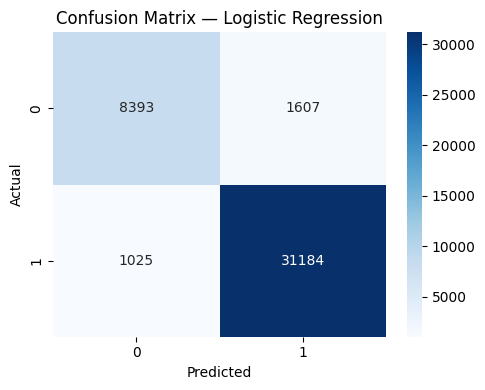

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [6]:
# ── 1. LOGISTIC REGRESSION ──────────────────────────────────
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
evaluate_model('Logistic Regression', lr, X_train_tfidf, X_test_tfidf, y_train, y_test)


  Model: Naive Bayes
  Accuracy  : 0.9341
  Precision : 0.9333  (weighted)
  Recall    : 0.9341  (weighted)
  F1-Score  : 0.9336  (weighted)
  ROC-AUC   : 0.9559
  MCC       : 0.8152
  Cohen's κ : 0.8148
  Train Time: 0.03s  |  Infer Time: 0.0050s

Classification Report:
              precision    recall  f1-score   support

           0     0.8789    0.8374    0.8576     10000
           1     0.9502    0.9642    0.9572     32209

    accuracy                         0.9341     42209
   macro avg     0.9146    0.9008    0.9074     42209
weighted avg     0.9333    0.9341    0.9336     42209



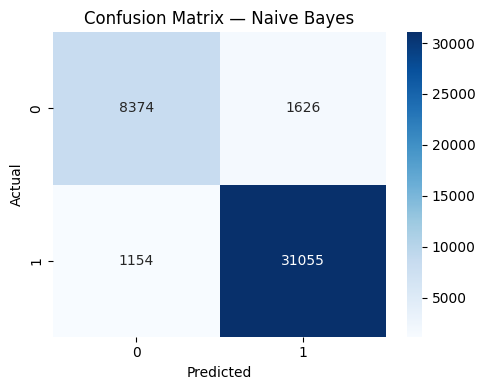

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [7]:
# ── 2. NAIVE BAYES ──────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler

# Scale to [0,1] for MultinomialNB (TF-IDF can have negatives with sublinear_tf)
scaler = MaxAbsScaler()
X_train_nb = scaler.fit_transform(X_train_tfidf)
X_test_nb  = scaler.transform(X_test_tfidf)

nb = MultinomialNB(alpha=0.1)
evaluate_model('Naive Bayes', nb, X_train_nb, X_test_nb, y_train, y_test)


  Model: SVM (LinearSVC)
  Accuracy  : 0.9384
  Precision : 0.9377  (weighted)
  Recall    : 0.9384  (weighted)
  F1-Score  : 0.9378  (weighted)
  ROC-AUC   : 0.9825
  MCC       : 0.8270
  Cohen's κ : 0.8265
  Train Time: 19.17s  |  Infer Time: 0.0233s

Classification Report:
              precision    recall  f1-score   support

           0     0.8909    0.8434    0.8665     10000
           1     0.9522    0.9679    0.9600     32209

    accuracy                         0.9384     42209
   macro avg     0.9215    0.9057    0.9132     42209
weighted avg     0.9377    0.9384    0.9378     42209



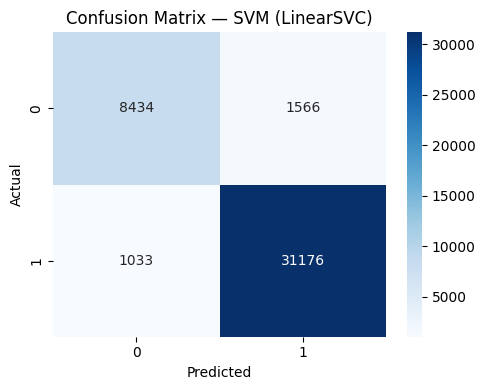

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [8]:
# ── 3. SUPPORT VECTOR MACHINE ───────────────────────────────
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_base = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm = CalibratedClassifierCV(svm_base)  # wrap for probability estimates
evaluate_model('SVM (LinearSVC)', svm, X_train_tfidf, X_test_tfidf, y_train, y_test, has_proba=True)


  Model: Random Forest
  Accuracy  : 0.9413
  Precision : 0.9406  (weighted)
  Recall    : 0.9413  (weighted)
  F1-Score  : 0.9408  (weighted)
  ROC-AUC   : 0.9839
  MCC       : 0.8354
  Cohen's κ : 0.8349
  Train Time: 32.98s  |  Infer Time: 0.2788s

Classification Report:
              precision    recall  f1-score   support

           0     0.8963    0.8508    0.8730     10000
           1     0.9544    0.9694    0.9619     32209

    accuracy                         0.9413     42209
   macro avg     0.9254    0.9101    0.9174     42209
weighted avg     0.9406    0.9413    0.9408     42209



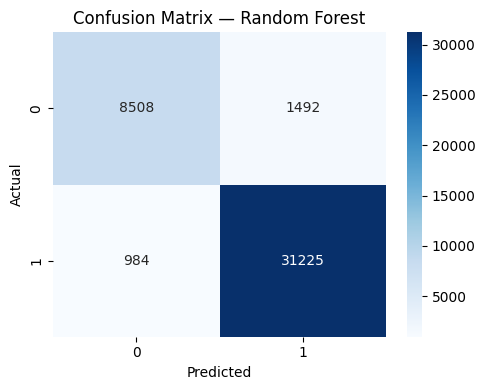

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# ── 4. RANDOM FOREST ────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
evaluate_model('Random Forest', rf, X_train_tfidf, X_test_tfidf, y_train, y_test)


  Model: XGBoost
  Accuracy  : 0.9412
  Precision : 0.9405  (weighted)
  Recall    : 0.9412  (weighted)
  F1-Score  : 0.9407  (weighted)
  ROC-AUC   : 0.9840
  MCC       : 0.8349
  Cohen's κ : 0.8345
  Train Time: 11.60s  |  Infer Time: 0.1392s

Classification Report:
              precision    recall  f1-score   support

           0     0.8961    0.8504    0.8727     10000
           1     0.9543    0.9694    0.9618     32209

    accuracy                         0.9412     42209
   macro avg     0.9252    0.9099    0.9172     42209
weighted avg     0.9405    0.9412    0.9407     42209



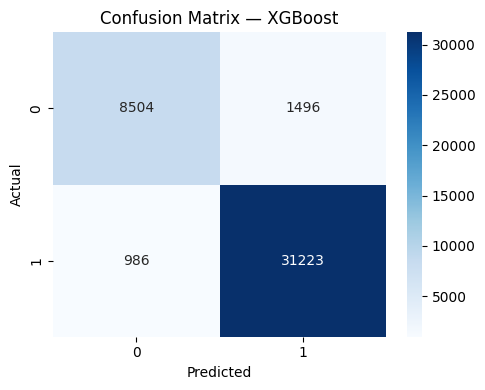

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [10]:
# ── 5. XGBOOST ──────────────────────────────────────────────
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1, random_state=42
)
evaluate_model('XGBoost', xgb, X_train_tfidf, X_test_tfidf, y_train, y_test)

In [11]:
# ── SUMMARY TABLE (Research Paper Ready) ────────────────────
results_df = pd.DataFrame(results_table)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('\n' + '='*90)
print('         COMPARATIVE RESULTS TABLE — ML MODELS (TON_IoT NLP Dataset)')
print('='*90)
print(results_df.to_string(index=False))
print('='*90)

results_df.to_csv('ml_results.csv', index=False)
print('\nSaved to ml_results.csv')


         COMPARATIVE RESULTS TABLE — ML MODELS (TON_IoT NLP Dataset)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC    MCC  Cohen's Kappa  Train Time(s)  Infer Time(s)
      Random Forest    0.9413     0.9406  0.9413    0.9408   0.9839 0.8354         0.8349          32.98         0.2788
            XGBoost    0.9412     0.9405  0.9412    0.9407   0.9840 0.8349         0.8345          11.60         0.1392
    SVM (LinearSVC)    0.9384     0.9377  0.9384    0.9378   0.9825 0.8270         0.8265          19.17         0.0233
Logistic Regression    0.9376     0.9368  0.9376    0.9370   0.9819 0.8246         0.8240           0.59         0.0020
        Naive Bayes    0.9341     0.9333  0.9341    0.9336   0.9559 0.8152         0.8148           0.03         0.0050

Saved to ml_results.csv


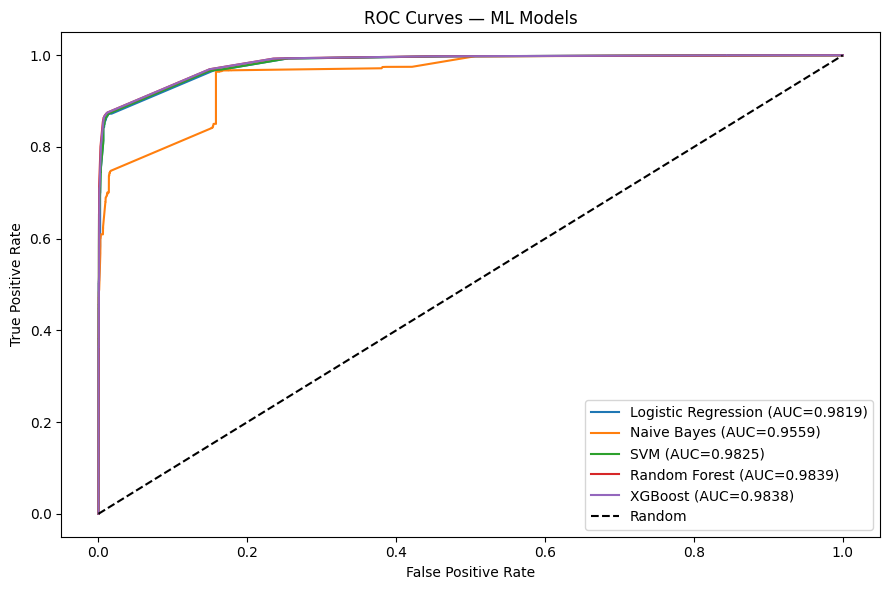

ROC curve saved.


In [12]:
# ── ROC CURVES (All Models) ─────────────────────────────────
from sklearn.metrics import roc_curve

# Re-collect probabilities for ROC plot
models_for_roc = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ('Naive Bayes', MultinomialNB(alpha=0.1)),
    ('SVM', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000, random_state=42))),
    ('Random Forest', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)),
    ('XGBoost', XGBClassifier(n_estimators=300, eval_metric='logloss', n_jobs=-1, random_state=42)),
]

plt.figure(figsize=(9, 6))
for name, m in models_for_roc:
    X_tr = X_train_nb if name == 'Naive Bayes' else X_train_tfidf
    X_te = X_test_nb  if name == 'Naive Bayes' else X_test_tfidf
    m.fit(X_tr, y_train)
    prob = m.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — ML Models')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig('roc_ml_models.png', dpi=150)
plt.show()
print('ROC curve saved.')

## Notes for Research Paper
- **Weighted** Precision/Recall/F1 used to handle class imbalance correctly.
- **MCC (Matthews Correlation Coefficient)**: more reliable than accuracy for imbalanced datasets.
- **Cohen's Kappa**: agreement metric robust to chance.
- **ROC-AUC**: measures discriminative ability across all thresholds.
- Report mean ± std from 5-fold CV for stronger claims.
